In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
dataset_path = "/content/drive/MyDrive/waste_dataset"

In [19]:
!ls "$dataset_path"

cardboard  glass  metal  paper	plastic  trash


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/waste_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/waste_dataset",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [21]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 560s 9s/step - accuracy: 0.2959 - loss: 1.8632 - val_accuracy: 0.2883 - val_loss: 1.7071
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.4427 - loss: 1.3563 - val_accuracy: 0.4076 - val_loss: 1.4420
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 257s 4s/step - accuracy: 0.5469 - loss: 1.1630 - val_accuracy: 0.4433 - val_loss: 1.3791
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.6270 - loss: 0.9753 - val_accuracy: 0.4811 - val_loss: 1.4827
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.7129 - loss: 0.7811 - val_accuracy: 0.5149 - val_loss: 1.4507
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.7875 - loss: 0.6003 - val_accuracy: 0.5089 - val_loss: 1.6227
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step - accuracy: 0.8463 - loss: 0.4463 - val_accuracy: 0.5030 - val_loss: 1.9580
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 285s 4s/step - accuracy: 0.8701 - loss: 0.3727 - val_accuracy: 0.4911 - v

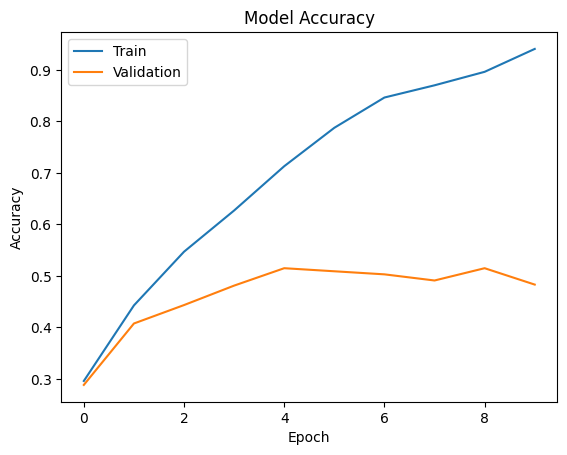

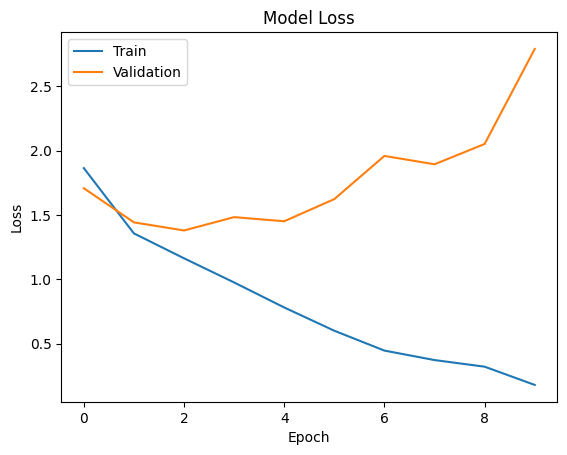

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.savefig('accuracy.png')
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('loss.png')
plt.show()

In [25]:
from google.colab import files
files.download('accuracy.png')
files.download('loss.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
model.save("model.h5")